In [42]:
from google.colab import drive
drive.mount('/content/drive')
data=("/content/drive/MyDrive/my/lfw-funneled.tgz")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [43]:
import tarfile
extract_path = "/content/lfw_dataset"
with tarfile.open(data, "r:gz") as tar:
    tar.extractall(path=extract_path)
print("Extraction Complete!")

/tmp/ipykernel_535/3604640865.py:4: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=extract_path)


Extraction Complete!


In [44]:
import os
os.listdir(extract_path)

['lfw_funneled']

In [45]:
dataset_path = "/content/lfw_dataset/lfw_funneled"

In [46]:
os.listdir(dataset_path)[:10]

['Albrecht_Mentz',
 'Karin_Stoiber',
 'Tom_Gamboa',
 'Columba_Bush',
 'Roger_Lyons',
 'Steve_Lenard',
 'Nicholoas_DiMarzio',
 'Julio_Cesar_Franco',
 'John_Cusack',
 'Jorge_Enrique_Jimenez']

In [24]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [47]:
images = []
labels = []
for person in os.listdir(dataset_path):
    person_path = os.path.join(dataset_path, person)
    if os.path.isdir(person_path):
        for image_name in os.listdir(person_path):
            image_path = os.path.join(person_path, image_name)
            img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
            if img is None:
                continue
            img = cv2.resize(img, (100,100))
            images.append(img.flatten())
            labels.append(person)

In [50]:
from collections import Counter

counter = Counter(labels)

valid_people = []

for person,count in counter.items():

    if count >= 20:
        valid_people.append(person)

X = []
y = []

for img,label in zip(images,labels):

    if label in valid_people:

        X.append(img)
        y.append(label)

X = np.array(X)
y = np.array(y)

print("\nFiltered Dataset")
print("Images :",X.shape)
print("Classes :",len(np.unique(y)))


Filtered Dataset
Images : (3023, 10000)
Classes : 62


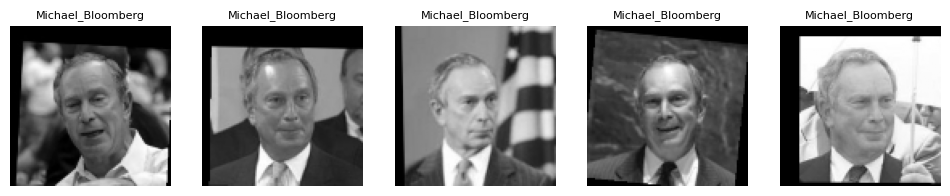

In [51]:
plt.figure(figsize=(12,5))

for i in range(5):

    plt.subplot(1,5,i+1)

    plt.imshow(X[i].reshape(100,100),cmap="gray")

    plt.title(y[i],fontsize=8)

    plt.axis("off")

plt.show()

In [55]:
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
print("Train Dataset Shape :", x_train.shape[0])
print("Test Dataset Shape  :", x_test.shape[0])

Train Dataset Shape : 2418
Test Dataset Shape  : 605


In [63]:
print(x_train.shape)

(2418, 150)


In [56]:
scale=StandardScaler()
x_train=scale.fit_transform(x_train)
x_test=scale.transform(x_test)

In [64]:
pca = PCA(
    n_components=0.95,
    whiten=True,
    random_state=42
)
x_train = pca.fit_transform(x_train)
x_test = pca.transform(x_test)

print("After PCA :", x_train.shape)


After PCA : (2418, 143)


In [65]:
knn = KNeighborsClassifier(
       n_neighbors=3,
    weights="distance",
    metric="euclidean"
)
knn.fit(x_train,y_train)

KNeighborsClassifier(metric='euclidean', n_neighbors=3, weights='distance')

In [66]:
y_pred = knn.predict(x_test)

In [67]:
print("\nAccuracy\n")
print(accuracy_score(y_test, y_pred))
print("\nClassification Report\n")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix\n")
print(confusion_matrix(y_test, y_pred))


Accuracy

0.2743801652892562

Classification Report

                           precision    recall  f1-score   support

         Alejandro_Toledo       0.20      0.12      0.15         8
             Alvaro_Uribe       0.50      0.14      0.22         7
          Amelie_Mauresmo       0.00      0.00      0.00         4
             Andre_Agassi       0.00      0.00      0.00         7
           Angelina_Jolie       0.00      0.00      0.00         4
             Ariel_Sharon       0.25      0.06      0.10        16
    Arnold_Schwarzenegger       0.00      0.00      0.00         8
     Atal_Bihari_Vajpayee       0.18      0.40      0.25         5
             Bill_Clinton       0.00      0.00      0.00         6
             Carlos_Menem       0.00      0.00      0.00         4
             Colin_Powell       0.53      0.49      0.51        47
            David_Beckham       0.43      0.50      0.46         6
          Donald_Rumsfeld       0.33      0.29      0.31        24
       

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [69]:
!pip install joblib

In [72]:
import joblib

joblib.dump(knn,"knn_face_model.pkl")
joblib.dump(scale,"scaler.pkl")
joblib.dump(pca,"pca.pkl")
print("\nModel Saved Successfully")


Model Saved Successfully


In [76]:
!git config --global user.name "chetan0722"
!git config --global user.email "sakherraj74@gmail.com"

In [77]:
!git config --global user.name
!git config --global user.email

chetan0722
sakherraj74@gmail.com


In [85]:
!pwd
!ls

/content
drive  knn_face_model.pkl  lfw_dataset	pca.pkl  sample_data  scaler.pkl


In [86]:
%%writefile /content/app.py

import streamlit as st
import cv2
import joblib
import numpy as np
from PIL import Image

model = joblib.load("knn_face_model.pkl")
scaler = joblib.load("scaler.pkl")
pca = joblib.load("pca.pkl")

st.title("Face Recognition using KNN")

uploaded_file = st.file_uploader("Upload Image", type=["jpg","png","jpeg"])

if uploaded_file is not None:

    image = Image.open(uploaded_file).convert("L")
    image = np.array(image)

    st.image(image)

    image = cv2.resize(image,(100,100))
    image = image.flatten().reshape(1,-1)

    image = scaler.transform(image)
    image = pca.transform(image)

    prediction = model.predict(image)

    st.success(prediction[0])

Writing /content/app.py
